In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM010_M_L-rotated2.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM002_M_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM010_M_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM013_F_R-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM011_F_L-sharpened.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM019_F_R-rotated2.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group/DM020_F_L-rotated1.png
/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabe

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
DATA_DIR = '/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"  # "Control Group" vs "DM Group"
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1444 files belonging to 2 classes.
Using 1156 files for training.


I0000 00:00:1784175522.373247      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784175522.376051      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1444 files belonging to 2 classes.
Using 288 files for validation.
Class names: ['Control Group', 'DM Group']


In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

base_model = keras.applications.EfficientNetV2B0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Keep the base backbone frozen for the initial warmup phase
base_model.trainable = False

# Construct the model pipeline
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)

# EfficientNet handles input scaling internally (0-255 expected)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary() 


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,920,593 (22.59 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [5]:
# Phase 1: Train the Head (Warm-up)
print("--- Phase 1: Training Classification Head ---")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

print("\n--- Phase 2: Unfreezing Top Layers for Fine-Tuning ---")
base_model.trainable = True

# Freeze everything except the top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a significantly lower learning rate to protect pre-trained weights
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3, 
    restore_best_weights=True
)

# Fine-tune the partially unfrozen backbone
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

--- Phase 1: Training Classification Head ---
Epoch 1/30


E0000 00:00:1784175536.716835      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.6791 - loss: 0.5911 - val_accuracy: 0.8160 - val_loss: 0.4538
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8244 - loss: 0.4231 - val_accuracy: 0.8299 - val_loss: 0.3891
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8573 - loss: 0.3681 - val_accuracy: 0.8403 - val_loss: 0.3496
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8737 - loss: 0.3365 - val_accuracy: 0.8333 - val_loss: 0.3248
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8746 - loss: 0.3151 - val_accuracy: 0.8472 - val_loss: 0.3049
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8815 - loss: 0.2923 - val_accuracy: 0.8576 - val_loss: 0.2885
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8815 - loss: 0.2782 - val_accuracy: 0.8785 - val_loss: 0.2868
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8884 - loss: 0.2713 - val_accuracy: 0.8681 - val_loss: 

E0000 00:00:1784175628.257025      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.9005 - loss: 0.2269 - val_accuracy: 0.8993 - val_loss: 0.2234
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9196 - loss: 0.2158 - val_accuracy: 0.9062 - val_loss: 0.2077
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9031 - loss: 0.2212 - val_accuracy: 0.9062 - val_loss: 0.2044
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9308 - loss: 0.2043 - val_accuracy: 0.9167 - val_loss: 0.1909
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9204 - loss: 0.1916 - val_accuracy: 0.9236 - val_loss: 0.1887
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9221 - loss: 0.1930 - val_accuracy: 0.9236 - val_loss: 0.1837
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9196 - loss: 0.1905 - val_accuracy: 0.9410 - val_loss: 0.1737
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9343 - loss: 0.1771 - val_accuracy: 0.9340 - val_loss: 

=== Validation Performance Metrics ===
Accuracy:      96.53%
Precision:     95.60%  (Out of all predicted DM, how many were actually DM?)
Recall/Sens:   98.06%  (Out of all actual DM, how many did we catch?)
F1-Score:      96.82%  (Harmonic mean of Precision and Recall)



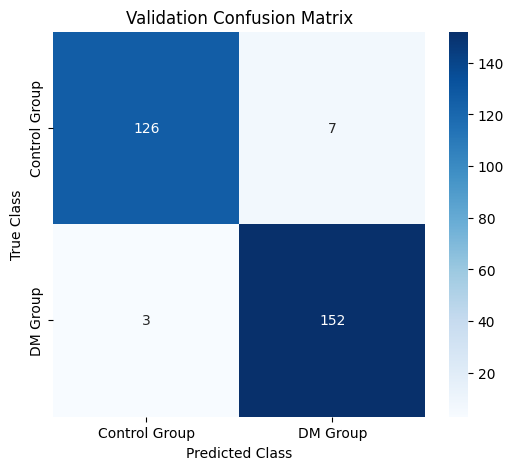

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

all_labels = []
all_preds = []

# Gather predictions across validation dataset
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    # Convert probability thresholds (0.5) to binary labels
    pred_labels = (preds > 0.5).astype(int)
    
    all_labels.extend(labels.numpy().flatten())
    all_preds.extend(pred_labels.flatten())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Compute Confusion Matrix parameters
accuracy = np.mean(all_labels == all_preds)
tp = np.sum((all_labels == 1) & (all_preds == 1))
fp = np.sum((all_labels == 0) & (all_preds == 1))
fn = np.sum((all_labels == 1) & (all_preds == 0))
tn = np.sum((all_labels == 0) & (all_preds == 0))

# Calculate Core Metrics
precision = tp / (tp + fp + 1e-7)
recall = tp / (tp + fn + 1e-7)  
f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)

# Print Summary Report
print("=== Validation Performance Metrics ===")
print(f"Accuracy:      {accuracy:.2%}")
print(f"Precision:     {precision:.2%}  (Out of all predicted DM, how many were actually DM?)")
print(f"Recall/Sens:   {recall:.2%}  (Out of all actual DM, how many did we catch?)")
print(f"F1-Score:      {f1_score:.2%}  (Harmonic mean of Precision and Recall)")
print("======================================\n")

# Generate Matrix Plot
cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()
